In [19]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, Engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv("../.env")

# start psql engine to grab data from database
def get_engine() -> Engine:
    '''
    Depending on .env, it will load localhost or online DB
    priority is online DB
    '''
    DATABASE_URL = os.environ.get("DATABASE_URL")

    if not DATABASE_URL:
        DB_USER = os.environ.get("DB_USER")
        DB_PASSWORD = os.environ.get("DB_PASSWORD")
        DB_HOST = os.environ.get("DB_HOST", "localhost")
        DB_PORT = os.environ.get("DB_PORT", "5432")
        DB_NAME = os.environ.get("DB_NAME")

        if not all([DB_USER, DB_PASSWORD, DB_NAME]):
            raise RuntimeError(
                "Set either DATABASE_URL, or DB_USER/DB_PASSWORD/DB_NAME in .env"
            )

        DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

    else:
        DATABASE_URL = f"postgresql+psycopg2://{DATABASE_URL}"

    return create_engine(DATABASE_URL)

engine = get_engine()

## Of the Asian coffee-producing countries, how much of their own coffee do they actually drink?

Using `coffee_domestic_consumption` (production-side table) against `coffee_production`, for the 10 Asian countries present in the dataset. A value under 100% means the country produces more coffee than it consumes at home (a net exporter of its own crop); over 100% means local demand outstrips local production, so the country relies on imports to cover the gap even though it's classified as a coffee grower. Diverging color at the 100% line makes that split visible at a glance.

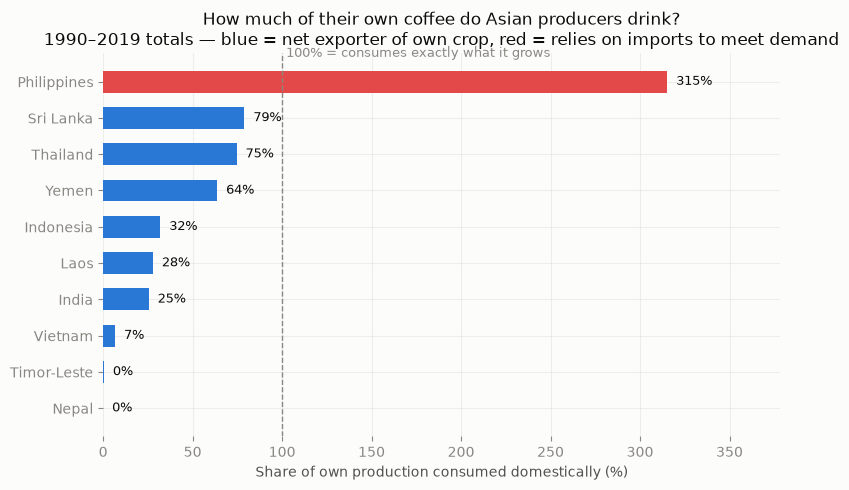

In [22]:
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
MUTED, GRID = "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "text.color": "#0b0b0b", "axes.labelcolor": "#52514e",
    "xtick.color": MUTED, "ytick.color": MUTED,
})

YEAR_COLS = [str(y) for y in range(1990, 2020)]

ASIA_PRODUCERS = [
    "India", "Indonesia", "Lao People's Democratic Republic", "Nepal",
    "Philippines", "Sri Lanka", "Thailand", "Timor-Leste", "Vietnam", "Yemen",
]
DISPLAY_NAMES = {"Lao People's Democratic Republic": "Laos"}

domestic = pd.read_sql("SELECT * FROM coffee_domestic_consumption", engine)
production = pd.read_sql("SELECT * FROM coffee_production", engine)

asia_domestic = domestic[domestic["country"].isin(ASIA_PRODUCERS)][["country", "total_domestic_consumption"]]
asia_production = production[production["country"].isin(ASIA_PRODUCERS)][["country", "total_production"]]

asia = asia_domestic.merge(asia_production, on="country")
asia["pct_domestic"] = asia["total_domestic_consumption"] / asia["total_production"] * 100
asia["country"] = asia["country"].replace(DISPLAY_NAMES)
asia = asia.sort_values("pct_domestic")

colors = [RED if v > 100 else BLUE for v in asia["pct_domestic"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(asia["country"], asia["pct_domestic"], color=colors, height=0.6)

ax.axvline(100, color=MUTED, linewidth=1, linestyle="--")
ax.text(100, len(asia) - 0.4, " 100% = consumes exactly what it grows",
        color=MUTED, fontsize=9, va="bottom")

for bar, value in zip(bars, asia["pct_domestic"]):
    ax.text(value + 5, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%",
            va="center", ha="left", fontsize=9, color="#0b0b0b")

ax.set_xlabel("Share of own production consumed domestically (%)")
ax.set_ylabel("")
ax.set_title(
    "How much of their own coffee do Asian producers drink?\n"
    "1990\u20132019 totals \u2014 blue = net exporter of own crop, red = relies on imports to meet demand"
)
ax.set_xlim(0, asia["pct_domestic"].max() * 1.2)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()